# Python Review 2 — Vectorization, CSVs, Debugging, & 3D Plots (10 ⭕️s)

## Overview

This notebook is a **Python warm-up/review** for Intro to AI Programming.  
You’ll practice using **NumPy vectorized operations**, **function structure**, **basic debugging**, **reading CSV files**, and **slightly fancier plotting**.

**Review Items:**
- Reading a CSV file into NumPy arrays
- Vectorized math with NumPy (no loops required)
- Writing functions that input arrays and return arrays
- Reading tracebacks, checking array shapes, and using `assert`
- 3D surface plotting with matplotlib

### Setup
Run the cell below. It imports the libraries you need and makes a CSV file for you to work with.

In [1]:
import csv
import math
import numpy as np
import matplotlib.pyplot as plt

# This creates a small csv in your working directory.
csv_filename = "review2_xy_data.csv"

# Create sample data
x_vals = np.linspace(0, 2*np.pi, 60) # 60 points from 0 to 2pi
y_vals = np.sin(x_vals) + 0.15*np.cos(3*x_vals) # Sample function with cosine noise

# Write the sample data to a CSV
with open(csv_filename, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["x", "y"])
    for x, y in zip(x_vals, y_vals):
        writer.writerow([float(x), float(y)])

print("Wrote:", csv_filename)

Wrote: review2_xy_data.csv


## **Task 1: CSV Access**


In [2]:
# Read the CSV into NumPy arrays

# Define the CSV filename
csv_filename = "review2_xy_data.csv"

# Initialize empty lists to hold x and y values
x_list = []
y_list = []

# Read the CSV file
with open(csv_filename, "r", newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        x_list.append(float(row["x"]))
        y_list.append(float(row["y"]))

# Convert lists to NumPy arrays
x = np.array(x_list)
y = np.array(y_list)

# Display the array shapes and first 5 values
print("x.shape:", x.shape)
print("y.shape:", y.shape)
print("First 5 x:", x[:5])
print("First 5 y:", y[:5])

x.shape: (60,)
y.shape: (60,)
First 5 x: [0.         0.10649467 0.21298933 0.319484   0.42597866]
First 5 y: [0.15       0.24870313 0.33178937 0.40029482 0.45651598]


## **Task 2: Sanity checks + simple plot**
1. Make a scatter plot of the raw points (`x`, `y`) with labels and title.

⭕️⭕️

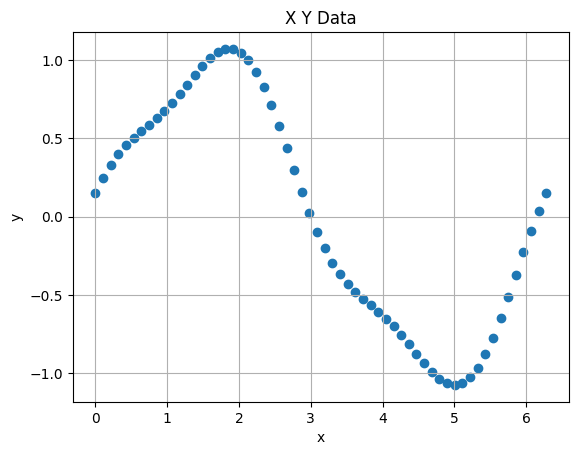

In [ ]:
# Sanity checks with assert statements

assert x.shape == y.shape, "x and y must have the same shape"
assert x.ndim == 1, "x must be 1D"

plt.scatter(x,y)
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.title('X Y Data')



## **Task 3: Vectorized functions**


In [7]:
# Create new arrays y_sin and y_cos without looping through the items of the NumPy array x
y_sin = np.sin(x)
y_cos = np.cos(x)

# Compute an operation on the new arrays without loops
y_combined = y_sin + 0.5 * y_cos

# Display the shapes of the new arrays
print("y_sin.shape:", y_sin.shape)
print("y_cos.shape:", y_cos.shape)
print("y_combined.shape:", y_combined.shape)

y_sin.shape: (60,)
y_cos.shape: (60,)
y_combined.shape: (60,)


## **Task 4: Vectorized linear and quadratic**
Compute these **vectorized** (no loops):
- Linear: $ y = ax + b $
- Quadratic: $ y = ax^2 + bx + c $

⭕️⭕️

Then plot each curve (line plot) on top of your raw scatter plot from task 2.

⭕️⭕️⭕️⭕️

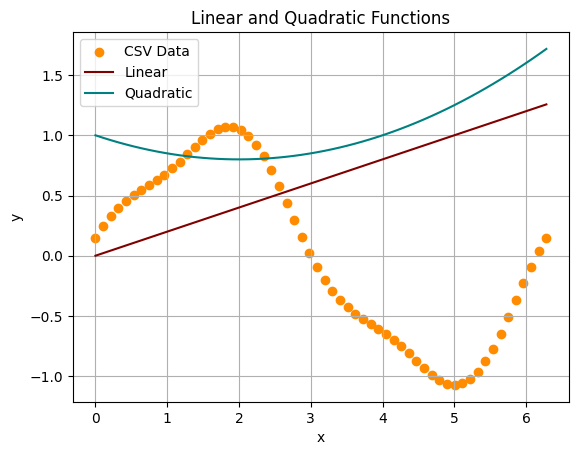

In [15]:
# Choose coefficients
a1, b1 = 0.2, 0.0
a2, b2, c2 = 0.05, -0.2, 1.0

y_linear = a1 * x + b1
y_quadratic = a2 * x ** 2 + b2 * x + c2

plt.scatter(x, y, color='darkorange', label='CSV Data')
plt.plot(x, y_linear, color='maroon', label='Linear')
plt.plot(x, y_quadratic, color='teal', label='Quadratic')
plt.grid()
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear and Quadratic Functions')
plt.show()


## **Task 5: Functions**


In [12]:
# Make a function that inputs an **array** and returns an **array**.

# Define a vectorized function for sin(x)
def h_sin(x_arr: np.ndarray) -> np.ndarray:
    """Return sin(x) for a NumPy array x_arr."""
    return np.sin(x_arr)

# Test the function
test = h_sin(x)
print("test.shape:", test.shape)

test.shape: (60,)


## **Task 6: Write two more array functions**
Write:
- `h_linear(x_arr)` returning a linear function
- `h_quadratic(x_arr)` returning a quadratic function

⭕️⭕️

Then plot their outputs over your `x` array.

⭕️⭕️

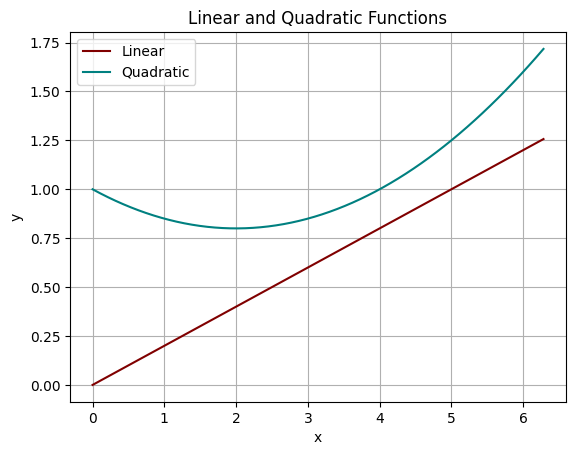

In [16]:
def h_linear(x_arr: np.ndarray) -> np.ndarray:
    return a1 * x_arr + b1

def h_quadratic(x_arr: np.ndarray) -> np.ndarray:
    return a2 * x_arr ** 2 + b2 * x_arr + c2

plt.plot(x, h_linear(x), color='maroon', label='Linear')
plt.plot(x, h_quadratic(x), color='teal', label='Quadratic')
plt.grid()
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear and Quadratic Functions')
plt.show()


## **Task 7: Debugging example**

In [17]:
# Example of a buggy function using the fact that ^ is not exponentiation in Python

# Define a buggy function that attempts to square an array with the wrong operator
def buggy_square(x_arr: np.ndarray) -> np.ndarray:
    """This function is supposed to square an array."""
    # BUG: uses XOR (^) instead of exponent (**)
    return x_arr ^ 2

# This will raise an error because ^ does not work for floating-point NumPy arrays
try:
    out = buggy_square(np.array([1.0, 2.0, 3.0]))
    print(out)
except Exception as e:
    print("Error message:")
    print(e)

Error message:
ufunc 'bitwise_xor' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''


## **Task 8: Fix the bug + add a guard**
1. Fix `buggy_square` so it squares correctly.
2. Add an `assert` that checks the input is a NumPy array or convert it.
3. Demonstrate it works by running it on a test input.

⭕️

In [25]:
def fixed_square(x_arr):
    assert isinstance(x_arr, (list, np.ndarray)), f'input is unprocessable type: {type(x_arr)}'
    if isinstance(x_arr, (list)): x_arr = np.array(x_arr)
    return x_arr ** 2

input = [1.0, 2.0, 3.0]
print(fixed_square(input)) # [1.0, 4.0, 9.0]
print(fixed_square(np.array(input))) # [1.0, 4.0, 9.0]
try:
    out = fixed_square('not a list or array')
    print(out)
except Exception as e:
    print("Error message:")
    print(e)


[1. 4. 9.]
[1. 4. 9.]
Error message:
input is unprocessable type: <class 'str'>


## **Task 9: 3D surface plot example**
We will plot a surface:

$ z = \sin(x)\cos(y) $

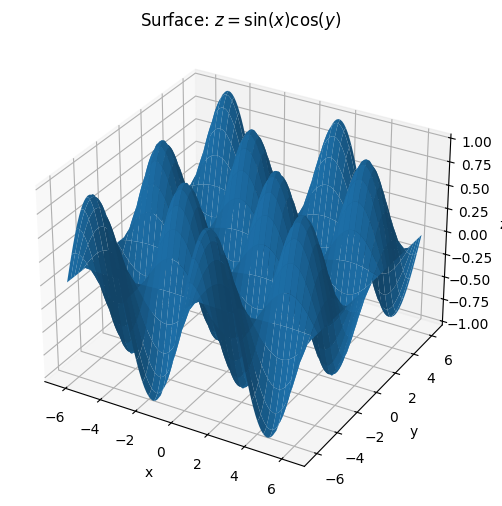

In [26]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Grid of points
u = np.linspace(-2*np.pi, 2*np.pi, 120)
v = np.linspace(-2*np.pi, 2*np.pi, 120)
U, V = np.meshgrid(u, v)

# Define the surface function
Z = np.sin(U) * np.cos(V)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(U, V, Z, linewidth=0, antialiased=True)

ax.set_title(r"Surface: $z=\sin(x)\cos(y)$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

## **Task 10: Modify + save the fancy plot**
Do **one** of the following to the 3D surface plot from Task 9:
- Change the grid range, **or**
- Change the viewing angle with `ax.view_init(elev=..., azim=...)`

⭕️⭕️

Plot a different surface (example: $Z = sin(U) + cos(V)$)

Make sure the plot is properly labeled and titled. Then **save** the figure and upload it to Canvas.

⭕️⭕️⭕️⭕️⭕️

**Filename convention:** `lastname_review2.png` (replace `lastname` with your last name)

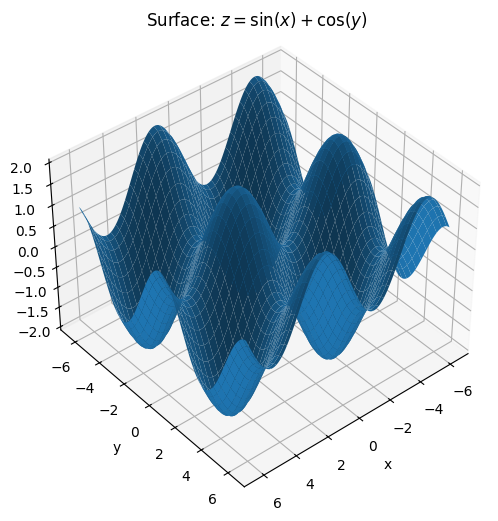

In [ ]:
# Grid of points
u = np.linspace(-2*np.pi, 2*np.pi, 120)
v = np.linspace(-2*np.pi, 2*np.pi, 120)
U, V = np.meshgrid(u, v)

# Define the surface function
Z = np.sin(U) + np.cos(V)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(U, V, Z, linewidth=0, antialiased=True)
ax.view_init(elev=40, azim=50)

ax.set_title(r"Surface: $z=\sin(x) + \cos(y)$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.savefig('ebent_review2.png', dpi=200, bbox_inches='tight')
plt.show()

### Submission Checklist
- [X] Complete the notebook
- [X] Save yout fancy plot as `lastname_review2.png`
- [X] Upload the PNG to Canvas
- [X] Export notebook to PDF and upload to Canvas